# Explore chemical space generated by each representation

In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from deepmol.loaders import CSVLoader
from sklearn.manifold import TSNE
import pandas as pd

def generate_tsne_with_featurizer(featurizer, name=None, method=TSNE):
    if not name:
        name = featurizer.__class__.__name__

    # Load and featurize data
    dataset = CSVLoader(dataset_path="../plant_cyc_pathways_w_labels_dedup.csv",
                      smiles_field="SMILES").create_dataset()
    dataset = featurizer.featurize(dataset)
    X = dataset.X

    # Perform t-SNE
    if method.__name__ == "TSNE":
        perplexity = min(30, X.shape[0] / 10)

        method_ = method(n_components=2, random_state=42, perplexity=perplexity)
    else:
        method_ = method(n_components=2, random_state=42)

    if method.__name__ == "UMAP":
        method_ = method(random_state=42)

    X_embedded = method_.fit_transform(X)

    # Load labels
    pandas_dataset = pd.read_csv("../plant_cyc_pathways_w_labels_dedup.csv")
    label_columns = pandas_dataset.columns[4:]
    label_counts = pandas_dataset[label_columns].sum().sort_values(ascending=False)
    most_frequent_labels = label_counts.index.tolist()[:30]

    # Assign classes
    def get_assigned_classes(row):
        for col in most_frequent_labels:
            if row[col] == 1:
                return col
        return "other"

    pandas_dataset['Assigned_Class'] = pandas_dataset.apply(get_assigned_classes, axis=1)

    # Define colors and markers
    opacity = 0.8
    colors = {
        'blue': (55/255, 126/255, 184/255, opacity),
        'orange': (255/255, 127/255, 0/255, opacity),
        'green': (77/255, 175/255, 74/255, opacity),
        'pink': (247/255, 129/255, 191/255, opacity),
        'brown': (166/255, 86/255, 40/255, opacity),
        'purple': (152/255, 78/255, 163/255, opacity),
        'lime': (50/255, 205/255, 50/255, opacity),  # Replaced gray with lime
        'red': (228/255, 26/255, 28/255, opacity),
        'yellow': (222/255, 222/255, 0/255, opacity),
        'cyan': (0/255, 183/255, 235/255, opacity),
        'dark_blue': (0/255, 0/255, 139/255, opacity),
    }

    # Marker styles
    markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'X', 'd']

    # Prepare color mapping
    color_values = list(colors.values())
    unique_classes = pandas_dataset["Assigned_Class"].unique().tolist()
    if "other" in unique_classes:
        unique_classes.remove("other")
        unique_classes.insert(0, "other")  # Put "Other" first

    # Create t-SNE plot
    plt.figure(figsize=(10, 8))
    legend_handles = []

    with open("pathway_dict.pkl", "rb") as f:
        pathway_dict = pickle.load(f)

    for key, value in pathway_dict.items():
        if "<i>" in str(value) or "</i>" in str(value):
            value = value.replace("<i>", "").replace("</i>", "")
            pathway_dict[key] = value

    pathway_dict["other"] = "other"

    for i, cls in enumerate(unique_classes):
        mask = pandas_dataset['Assigned_Class'] == cls
        color = color_values[i % len(color_values)]
        marker = markers[i % len(markers)]
        if "nan" not in str(pathway_dict[cls]):
            cls = pathway_dict[cls]

        # Plot with both color and marker
        plt.scatter(X_embedded[mask, 0], X_embedded[mask, 1],
                   color=color,
                   label=cls,
                   s=30,
                   marker=marker,
                   alpha=opacity)

        # Create legend handle with both color and marker
        legend_handles.append(plt.Line2D([0], [0],
                                       marker=marker,
                                       color='w',
                                       label=cls,
                                       markerfacecolor=color,
                                       markersize=7))

    plt.title(f'{method.__name__} plot of {name}', size=17)
    plt.grid(True)
    plt.xlabel(f'{method.__name__} 1')
    plt.ylabel(f'{method.__name__} 2')
    plt.tight_layout()
    plt.savefig(f"{method.__name__}_plot_{name}.png", bbox_inches='tight', dpi=300, transparent=True)

    # Create separate legend figure
    fig_legend = plt.figure(figsize=(10, 0.5))
    fig_legend.legend(handles=legend_handles,
                     loc='center',
                     ncol=1,
                     title="Pathway")
    fig_legend.savefig(f"{method.__name__}_legend_{name}.png", bbox_inches='tight', dpi=300, transparent=True)
    plt.close(fig_legend)


/home/jcapela/.local/share/mamba/envs/np_benchmark/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/jcapela/.local/share/mamba/envs/np_benchmark/lib/python3.10/site-packages/umap/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
NPClassifierFP: 100%|██████████| 1640/1640 [00:02<00:00, 754.64it/s]


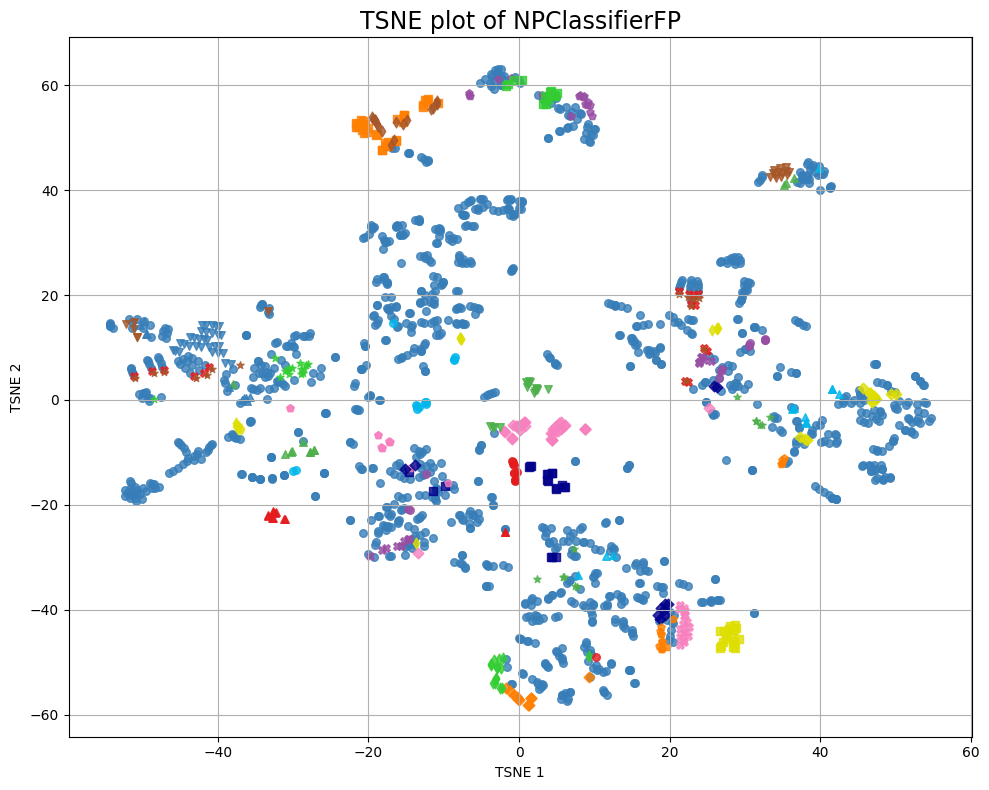

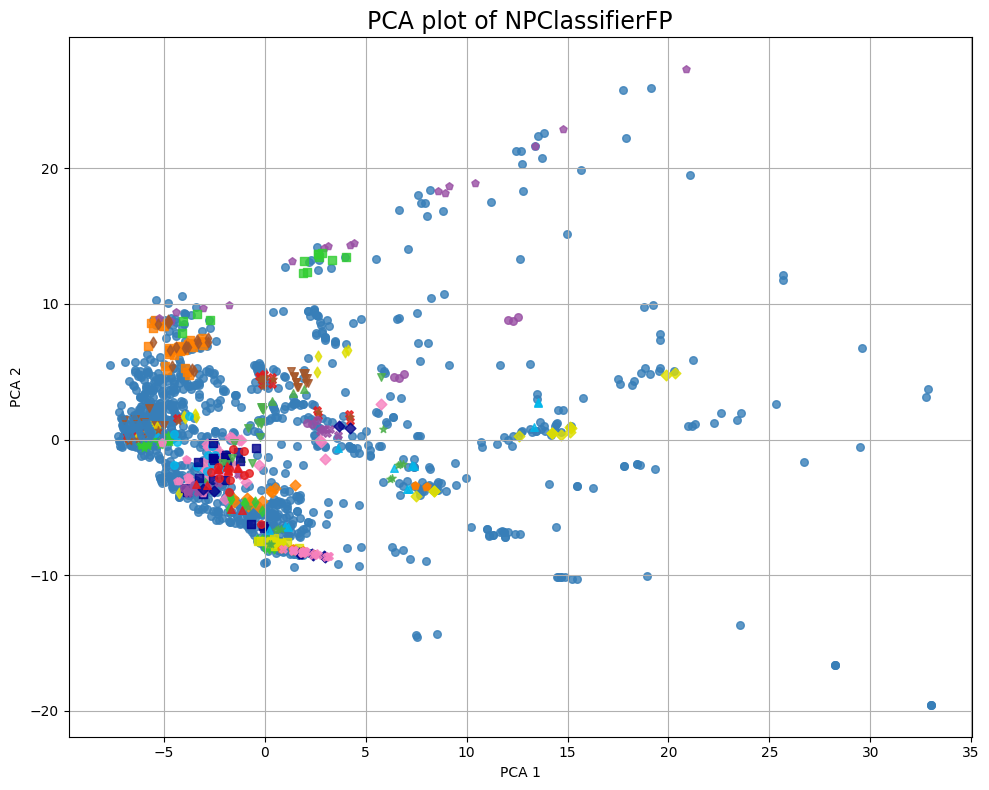

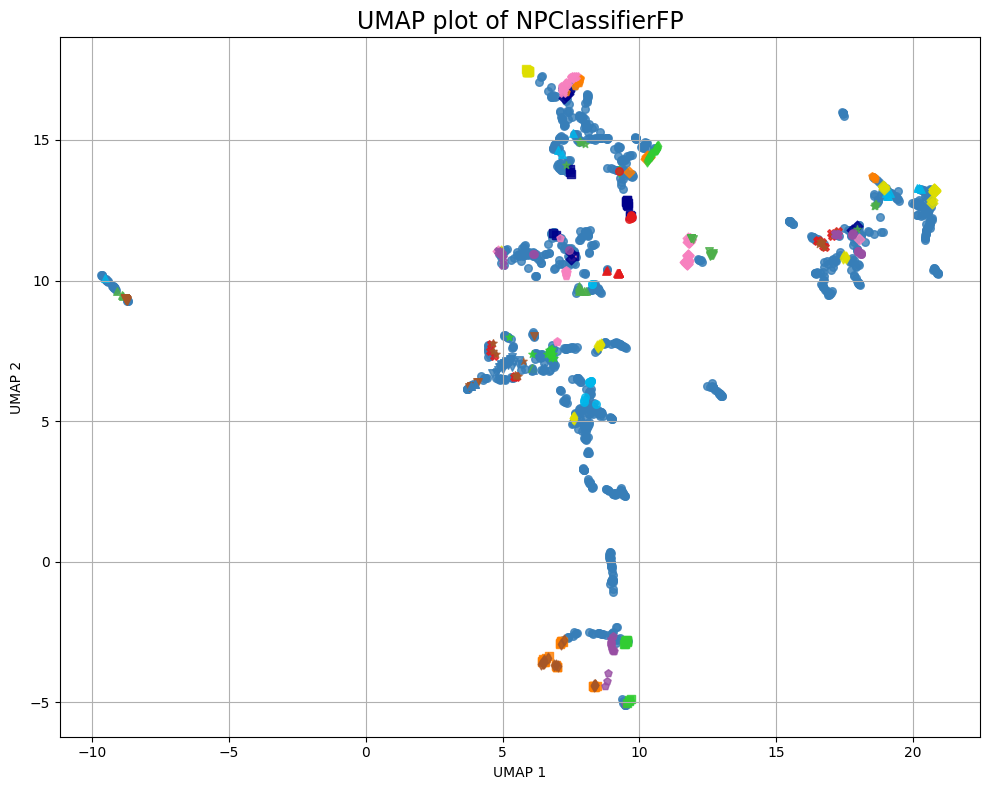

In [2]:
from deepmol.compound_featurization import NPClassifierFP
from sklearn.decomposition import PCA
import umap

featurizer = NPClassifierFP()
generate_tsne_with_featurizer(featurizer)
generate_tsne_with_featurizer(featurizer, method=PCA)
generate_tsne_with_featurizer(featurizer, method=umap.UMAP)

NeuralNPFP: 100%|██████████| 1640/1640 [00:05<00:00, 303.53it/s]


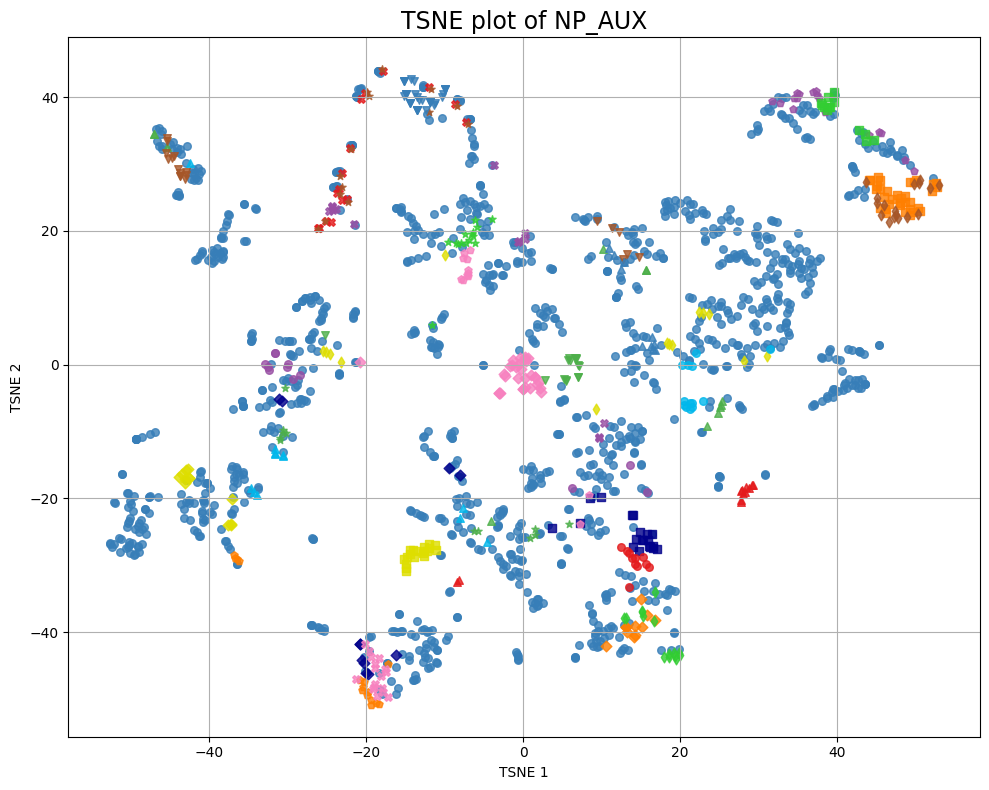

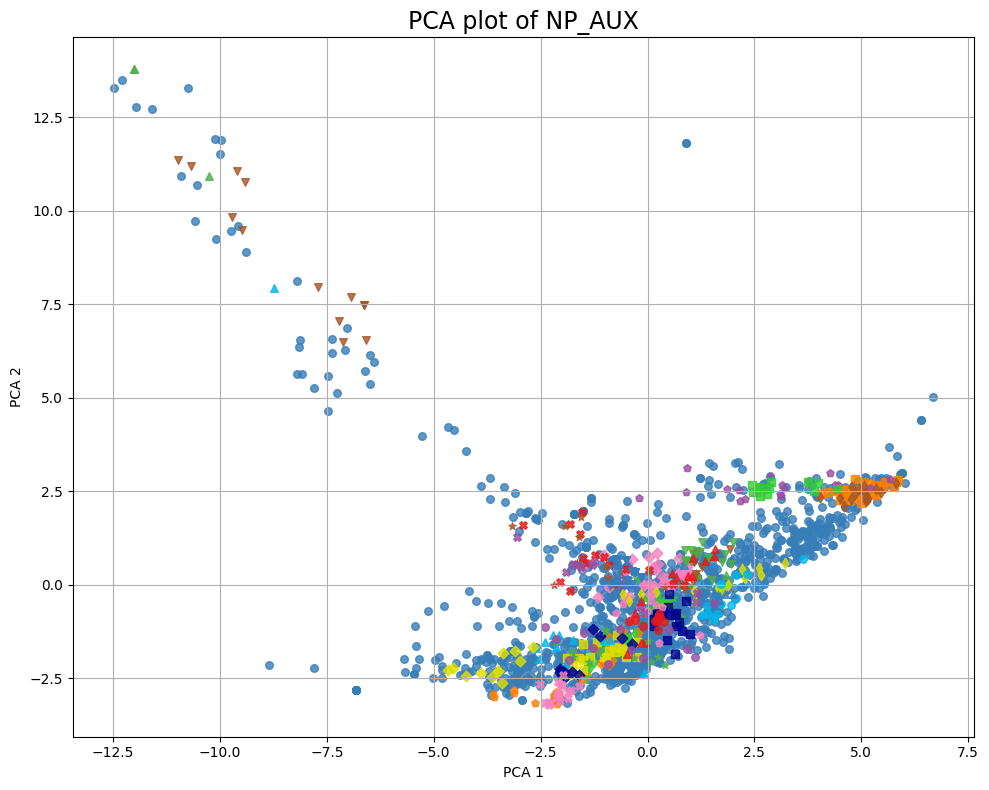

In [12]:
from deepmol.compound_featurization import NeuralNPFP

featurizer = NeuralNPFP()
generate_tsne_with_featurizer(featurizer, name="NP_AUX")
generate_tsne_with_featurizer(featurizer, name="NP_AUX", method=PCA)

BiosynfoniKeys: 100%|██████████| 1640/1640 [00:02<00:00, 625.82it/s]


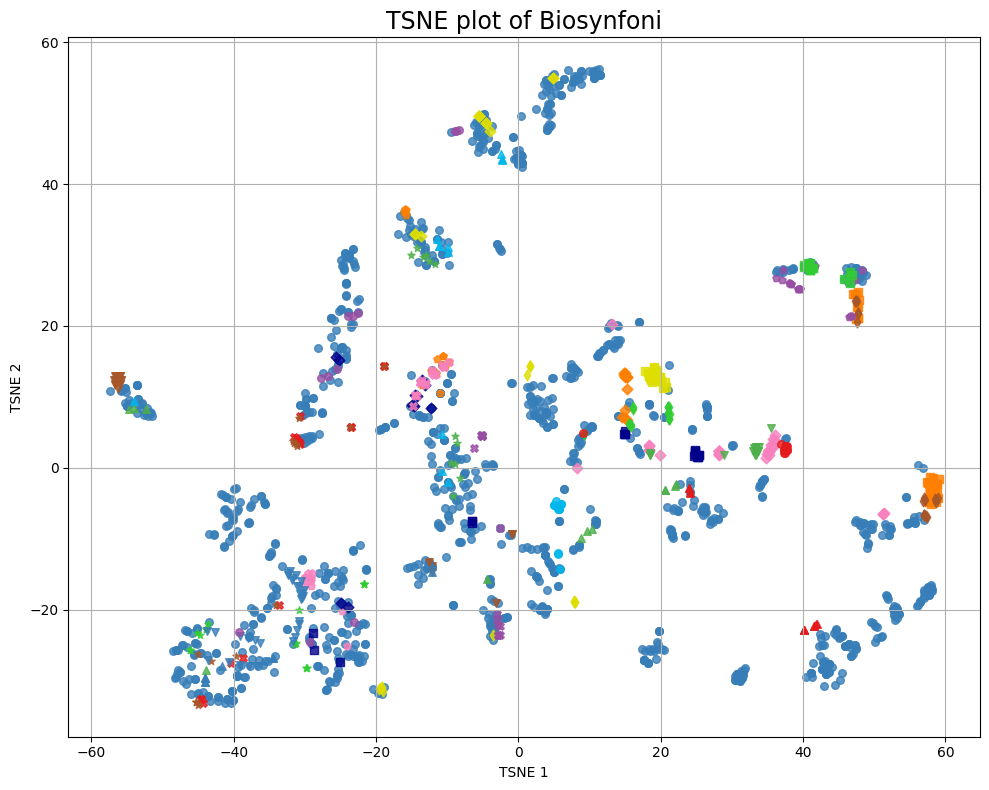

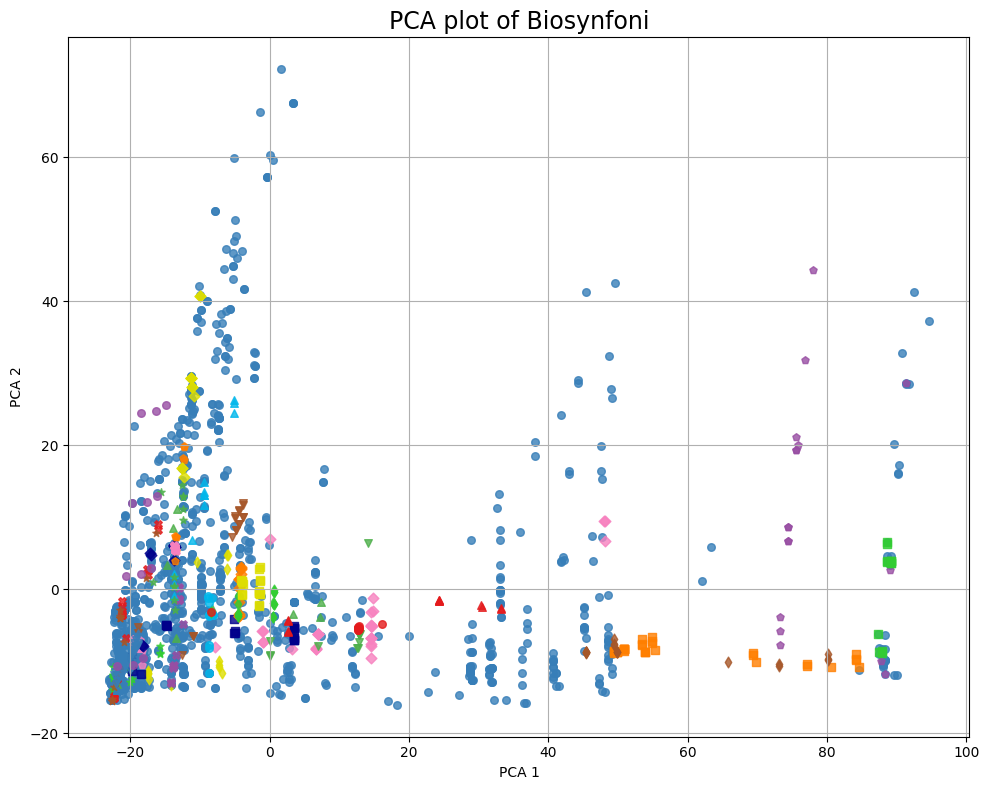

In [13]:
from deepmol.compound_featurization import BiosynfoniKeys

featurizer = BiosynfoniKeys()
generate_tsne_with_featurizer(featurizer, name="Biosynfoni")
generate_tsne_with_featurizer(featurizer, name="Biosynfoni", method=PCA)

Some weights of BertModel were not initialized from the model checkpoint at ../../NPBERT/model.pt and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


100%|██████████| 1640/1640 [00:09<00:00, 175.63it/s]


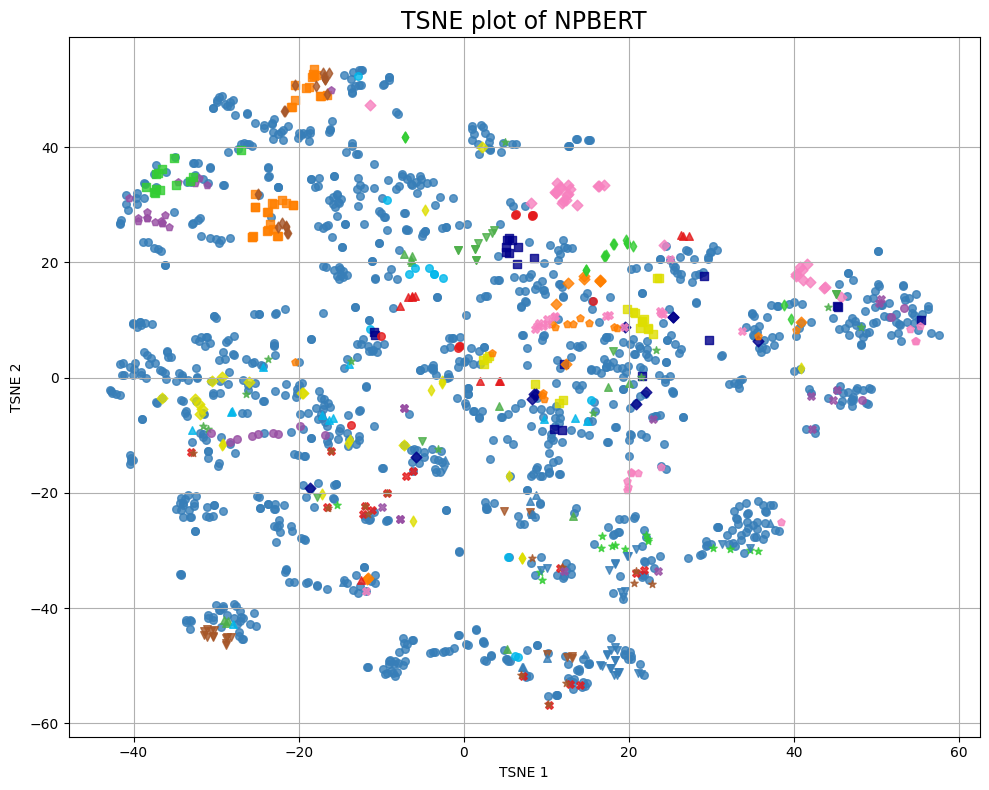

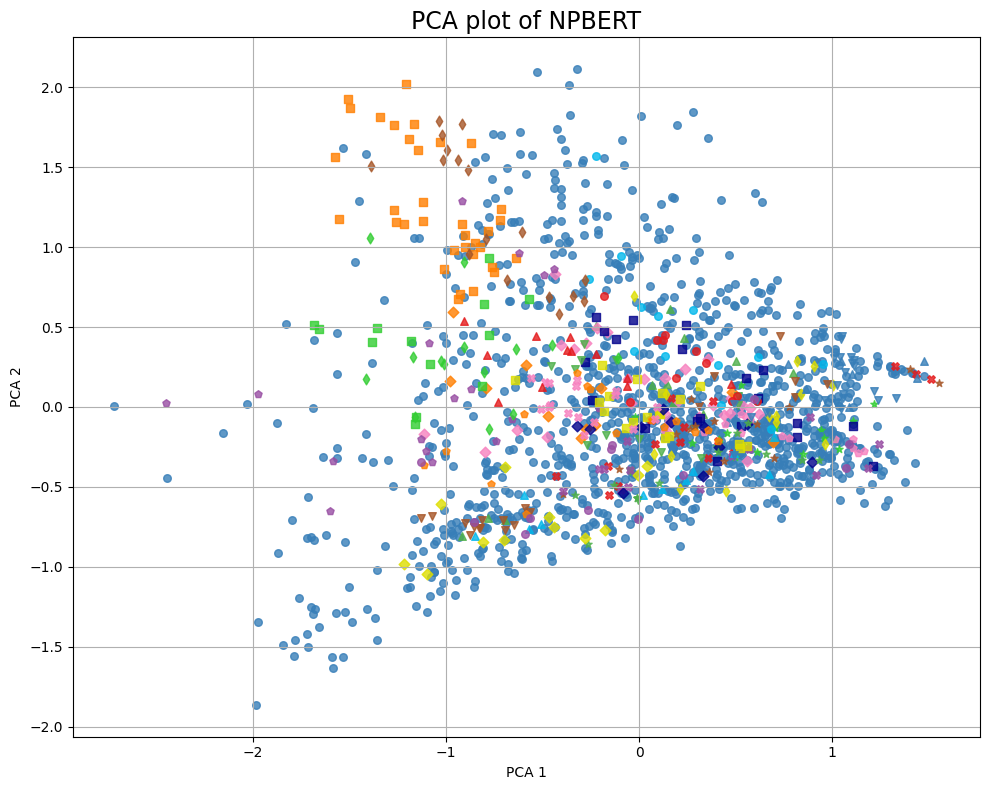

In [14]:
import os
from deepmol.compound_featurization import LLM
from transformers import BertConfig, BertModel

from deepmol.standardizer import ChEMBLStandardizer

from deepmol.tokenizers import NPBERTTokenizer

transformer = LLM(model_path="../../NPBERT", model=BertModel, config_class=BertConfig,
                          tokenizer=NPBERTTokenizer(vocab_file=os.path.join("../../NPBERT", "vocab.txt")), device="cuda:0")

generate_tsne_with_featurizer(transformer, name="NPBERT")
generate_tsne_with_featurizer(transformer, name="NPBERT", method=PCA)

100%|██████████| 1640/1640 [00:58<00:00, 28.17it/s]


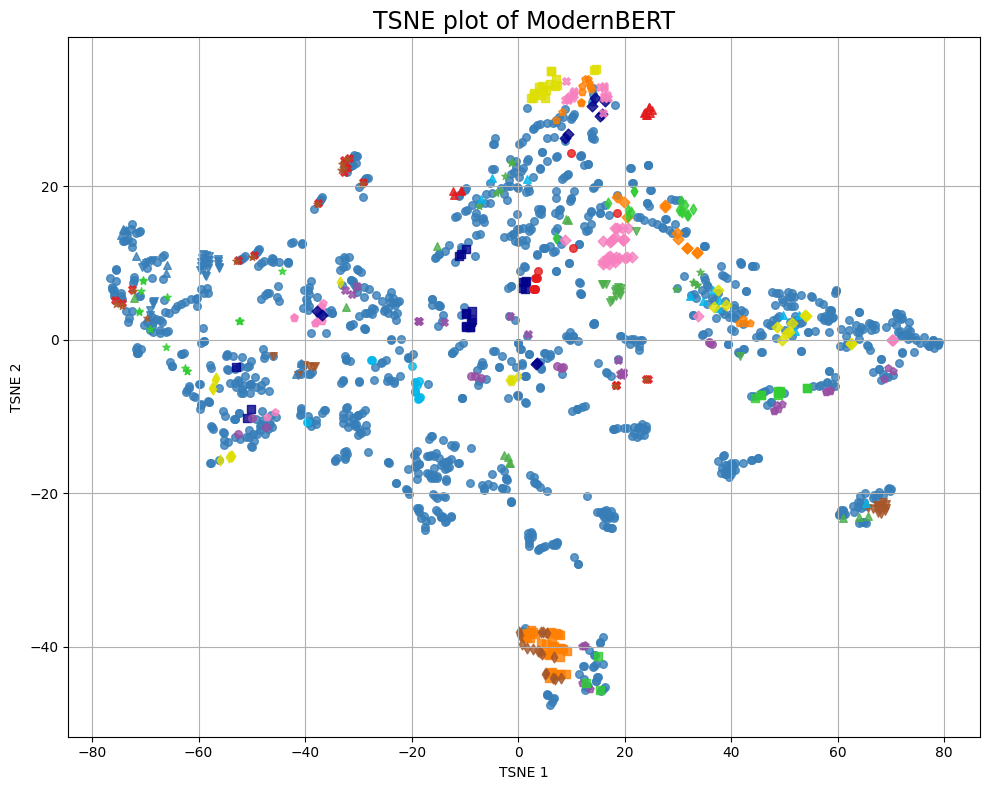

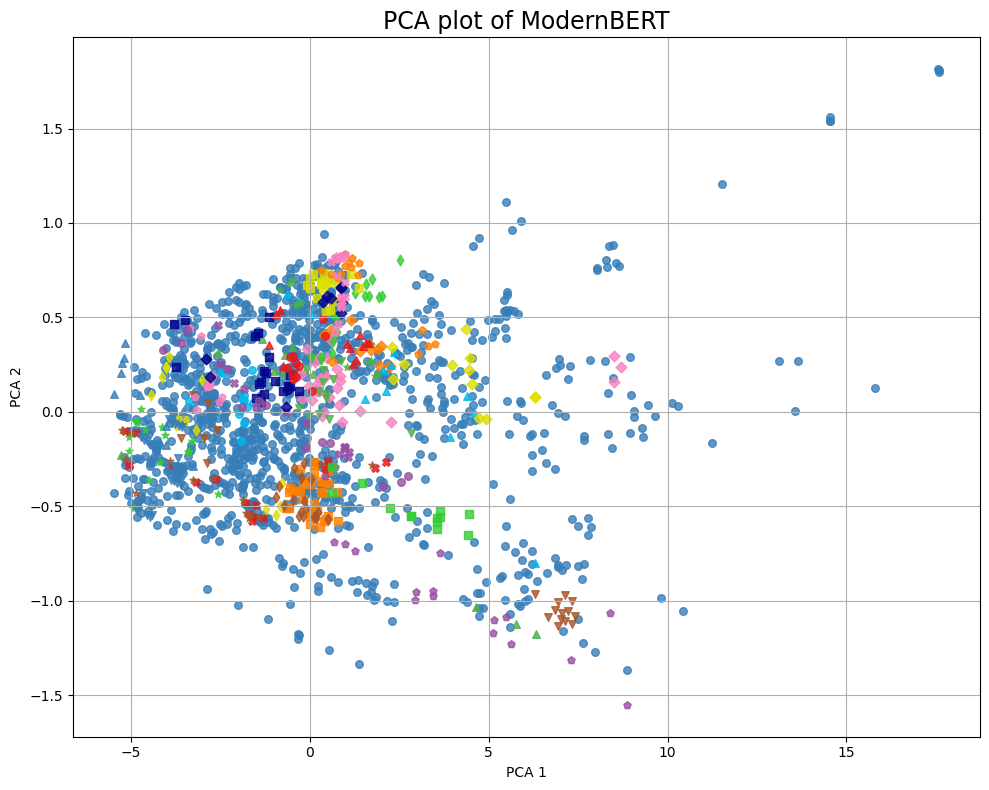

In [9]:
import os
from deepmol.compound_featurization import LLM

from deepmol.compound_featurization import LLM
from transformers import ModernBertModel, ModernBertConfig

transformer = LLM(model_path="../../ModernBERT", model=ModernBertModel, config_class=ModernBertConfig, device="cuda:1")

generate_tsne_with_featurizer(transformer, name="ModernBERT")
generate_tsne_with_featurizer(transformer, name="ModernBERT", method=PCA)

MorganFingerprint: 100%|██████████| 1640/1640 [00:02<00:00, 779.23it/s]


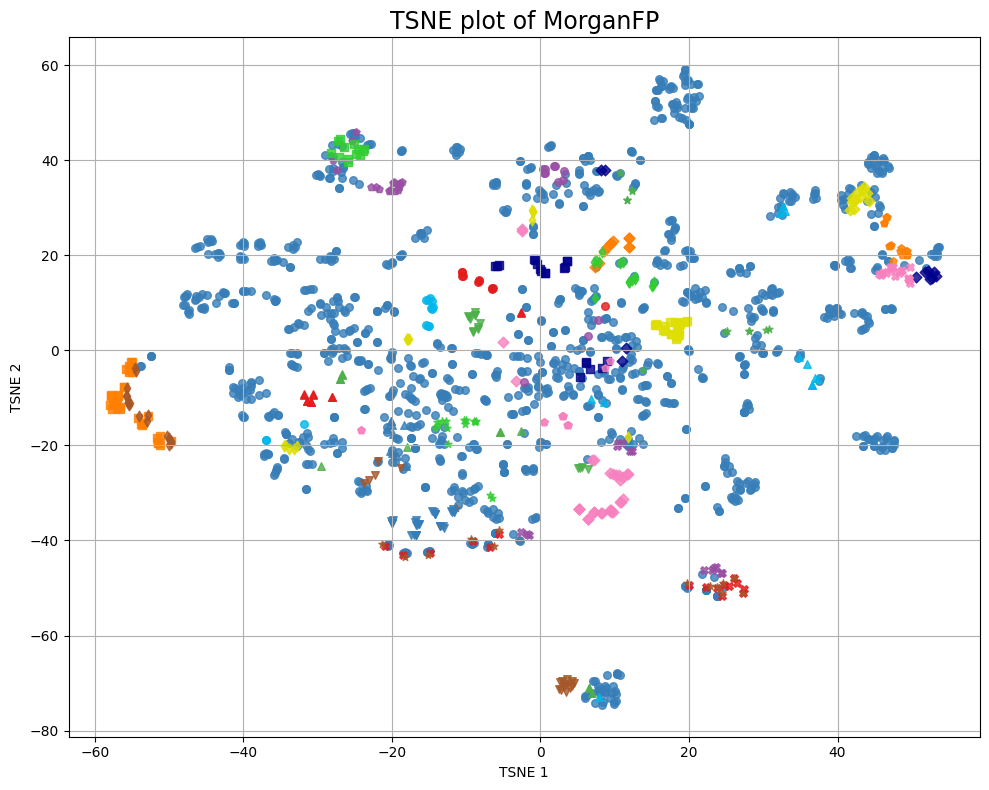

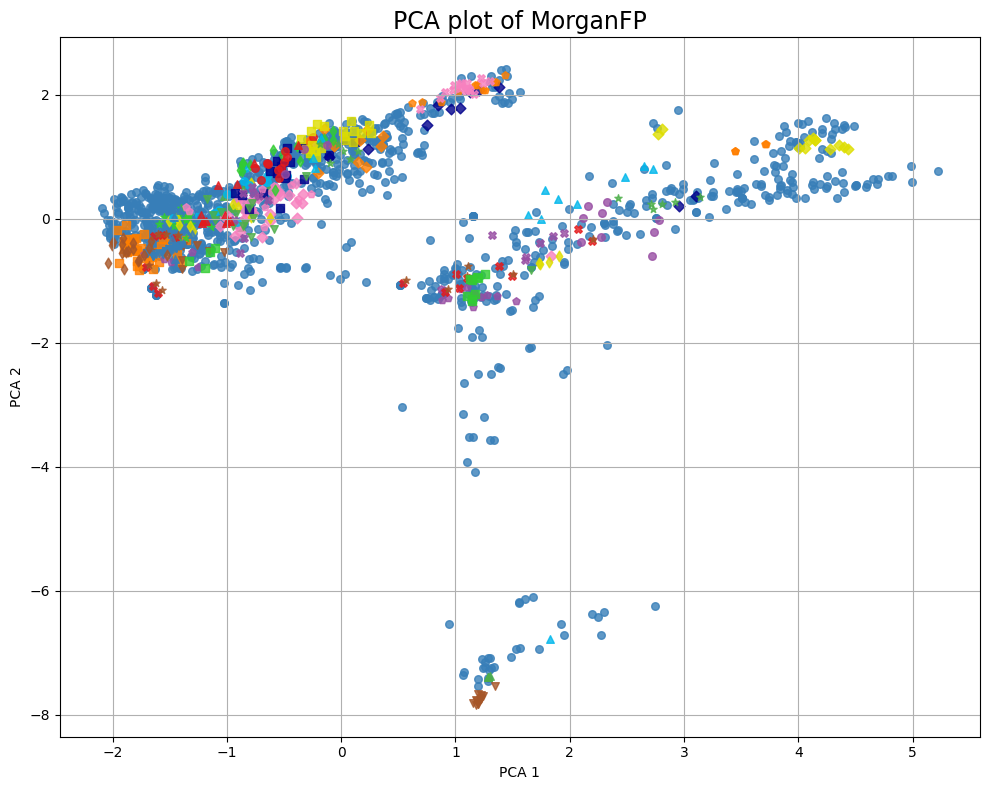

In [15]:
from deepmol.compound_featurization import MorganFingerprint

featurizer = MorganFingerprint()
generate_tsne_with_featurizer(featurizer, name="MorganFP")
generate_tsne_with_featurizer(featurizer, name="MorganFP", method=PCA)

MHFP:   0%|          | 0/1640 [00:00<?, ?it/s]

MHFP: 100%|██████████| 1640/1640 [00:21<00:00, 75.71it/s] 


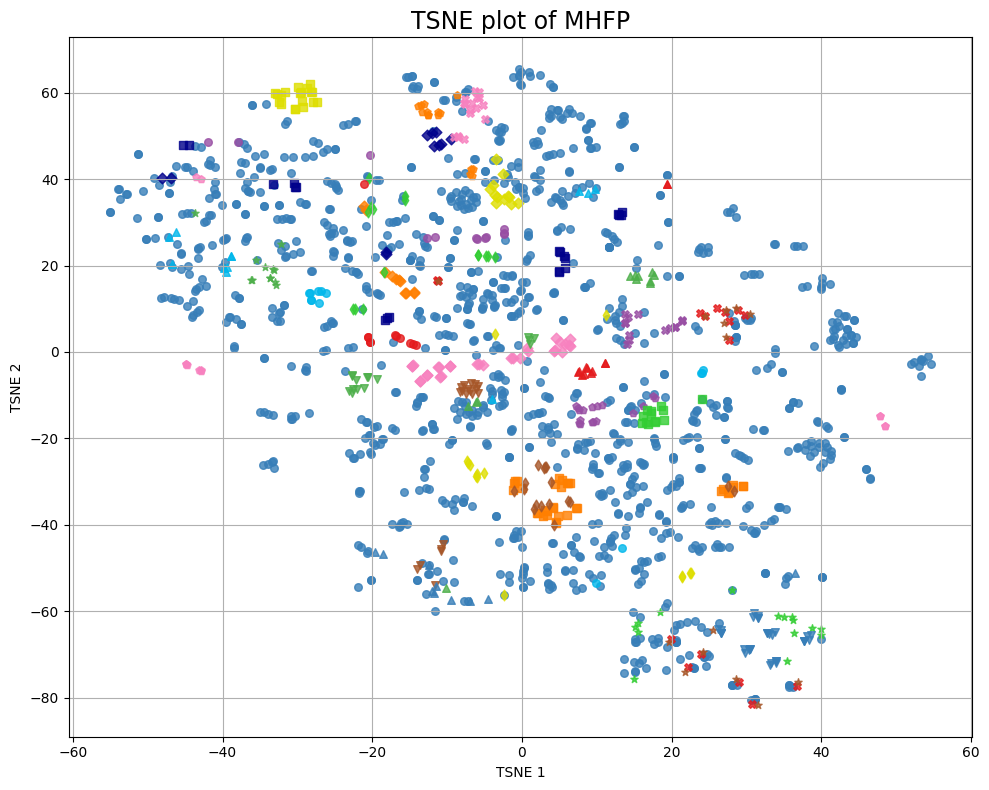

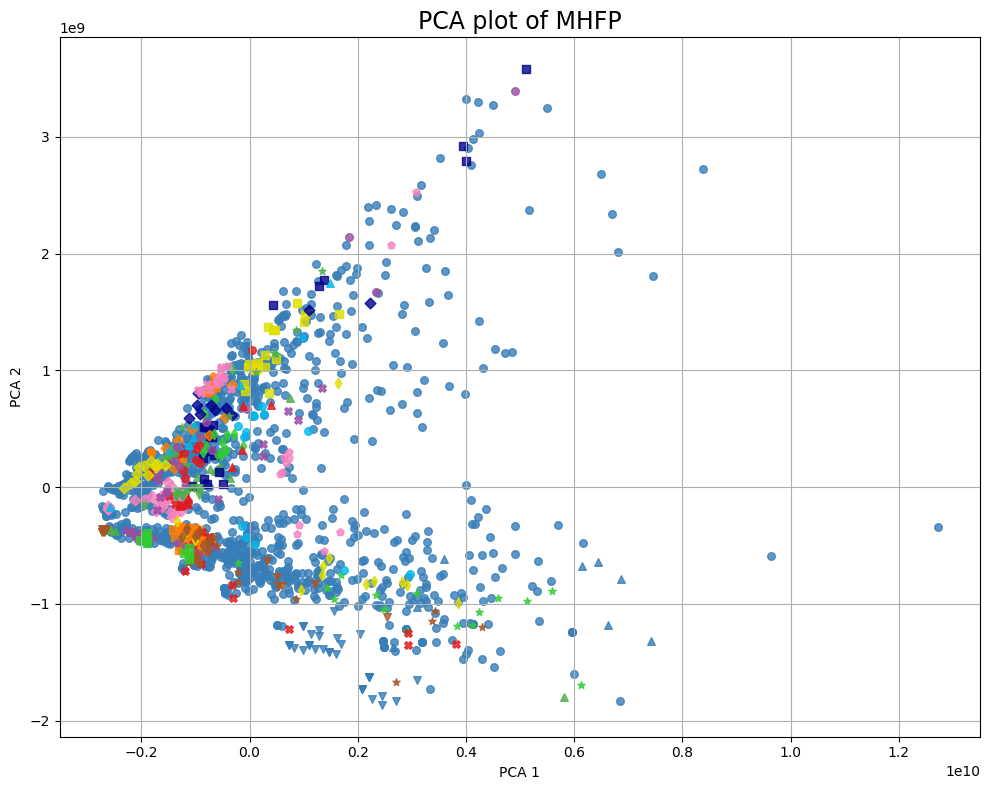

In [11]:
from deepmol.compound_featurization import MHFP

featurizer = MHFP()
generate_tsne_with_featurizer(featurizer)
generate_tsne_with_featurizer(featurizer, method=PCA)